# Praktikum Decision Tree Classifier

1. Binary Classification, menggunakan dataset Breast Cancer
2. Multiclass Classification, menggunakan dataset Iris

## 0. Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

---

# Bagian 1: Binary Classification (Breast Cancer Dataset)

Dataset ini berisi hasil pengukuran sel tumor, dengan target berupa 2 kelas: malignant (ganas) dan benign (jinak).

## 1.1 Load Dataset

In [2]:
data = load_breast_cancer()
X = data.data
y = data.target

print("Jumlah sampel:", X.shape[0])
print("Jumlah fitur:", X.shape[1])
print("Nama kelas:", data.target_names)
print("Distribusi kelas:", np.bincount(y))

Jumlah sampel: 569
Jumlah fitur: 30
Nama kelas: ['malignant' 'benign']
Distribusi kelas: [212 357]


## 1.2 Eksplorasi Data Singkat

In [3]:
df = pd.DataFrame(X, columns=data.feature_names)
df["target"] = y
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 1.3 Split Data Training dan Testing

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Jumlah data training:", X_train.shape[0])
print("Jumlah data testing:", X_test.shape[0])

Jumlah data training: 455
Jumlah data testing: 114


## 1.4 Training Model Decision Tree

Menggunakan kriteria split Gini Impurity dengan regularisasi max_depth dan min_samples_leaf.

In [5]:
dt_binary = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    min_samples_leaf=5,
    random_state=42
)

dt_binary.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## 1.5 Evaluasi Model

In [6]:
y_pred = dt_binary.predict(X_test)

print("Akurasi:", accuracy_score(y_test, y_pred))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

Akurasi: 0.9210526315789473

Classification Report:
              precision    recall  f1-score   support

   malignant       0.88      0.90      0.89        42
      benign       0.94      0.93      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



## 1.6 Confusion Matrix

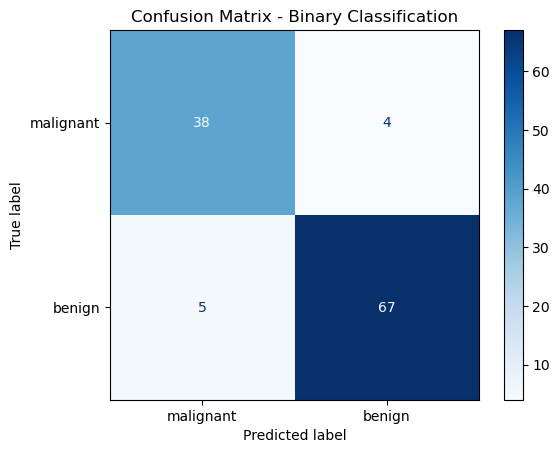

In [7]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Binary Classification")
plt.show()

## 1.7 Visualisasi Tree


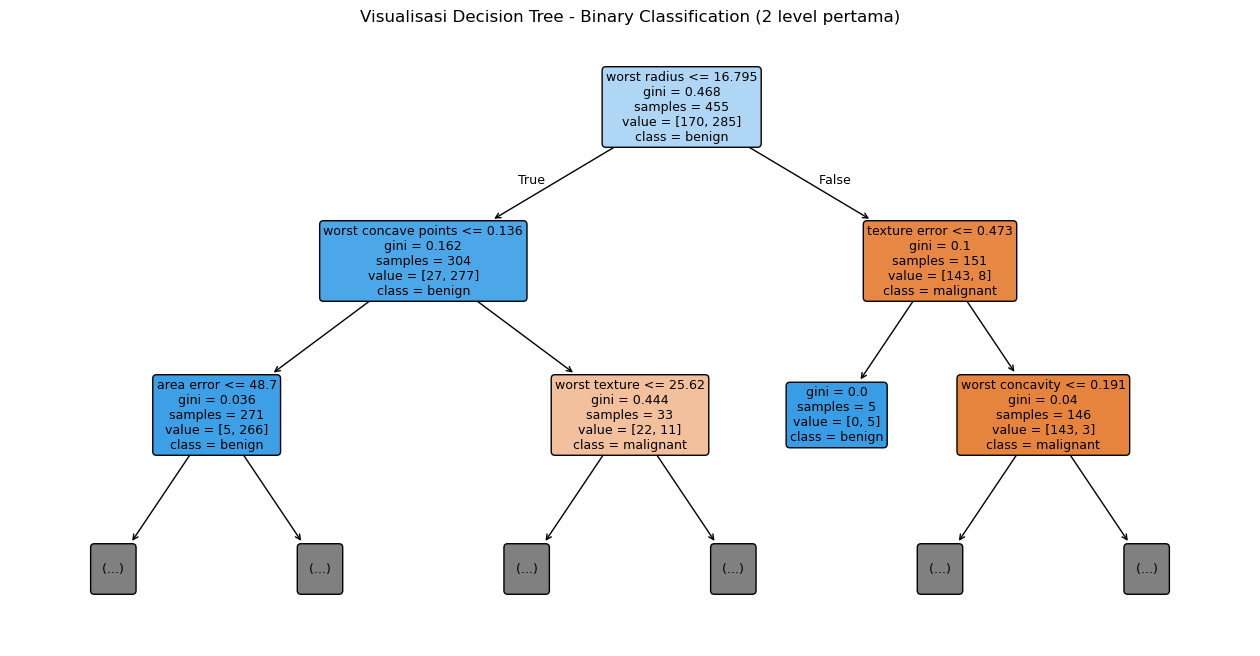

In [8]:
plt.figure(figsize=(16, 8))
plot_tree(
    dt_binary,
    filled=True,
    rounded=True,
    feature_names=data.feature_names,
    class_names=data.target_names,
    max_depth=2
)
plt.title("Visualisasi Decision Tree - Binary Classification (2 level pertama)")
plt.show()

## 1.8 Feature Importance

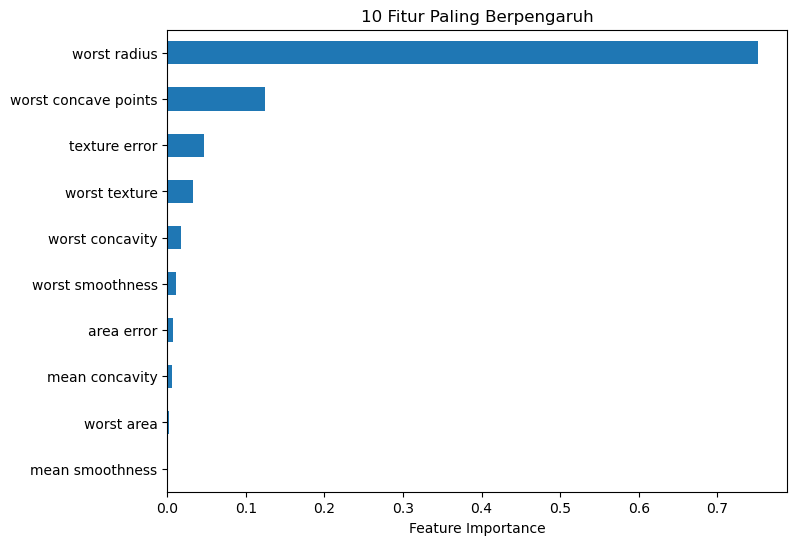

In [9]:
importances = pd.Series(dt_binary.feature_importances_, index=data.feature_names)
importances = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 6))
importances.plot(kind="barh")
plt.title("10 Fitur Paling Berpengaruh")
plt.xlabel("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

---

# Bagian 2: Multiclass Classification (Iris Dataset)

Dataset klasik dengan 3 kelas bunga iris (setosa, versicolor, virginica), masing-masing dengan 4 fitur pengukuran kelopak dan mahkota bunga.

## 2.1 Load Dataset

In [10]:
iris = load_iris()
X2 = iris.data
y2 = iris.target

print("Jumlah sampel:", X2.shape[0])
print("Jumlah fitur:", X2.shape[1])
print("Nama kelas:", iris.target_names)
print("Distribusi kelas:", np.bincount(y2))

Jumlah sampel: 150
Jumlah fitur: 4
Nama kelas: ['setosa' 'versicolor' 'virginica']
Distribusi kelas: [50 50 50]


## 2.2 Eksplorasi Data Singkat

In [11]:
df_iris = pd.DataFrame(X2, columns=iris.feature_names)
df_iris["target"] = y2
df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 2.3 Split Data Training dan Testing

In [12]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

print("Jumlah data training:", X2_train.shape[0])
print("Jumlah data testing:", X2_test.shape[0])

Jumlah data training: 120
Jumlah data testing: 30


## 2.4 Training Model Decision Tree

Kali ini menggunakan kriteria split Entropy, sebagai perbandingan dengan Gini yang dipakai di bagian 1.

In [13]:
dt_multi = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    min_samples_leaf=3,
    random_state=42
)

dt_multi.fit(X2_train, y2_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## 2.5 Evaluasi Model

In [14]:
y2_pred = dt_multi.predict(X2_test)

print("Akurasi:", accuracy_score(y2_test, y2_pred))
print()
print("Classification Report:")
print(classification_report(y2_test, y2_pred, target_names=iris.target_names))

Akurasi: 0.9666666666666667

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## 2.6 Confusion Matrix

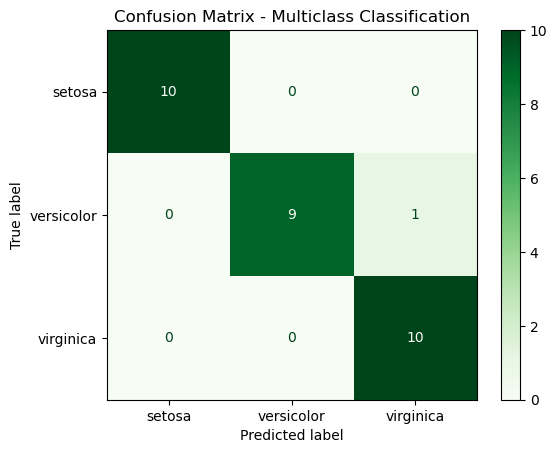

In [15]:
cm2 = confusion_matrix(y2_test, y2_pred)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=iris.target_names)
disp2.plot(cmap="Greens")
plt.title("Confusion Matrix - Multiclass Classification")
plt.show()

## 2.7 Visualisasi Tree

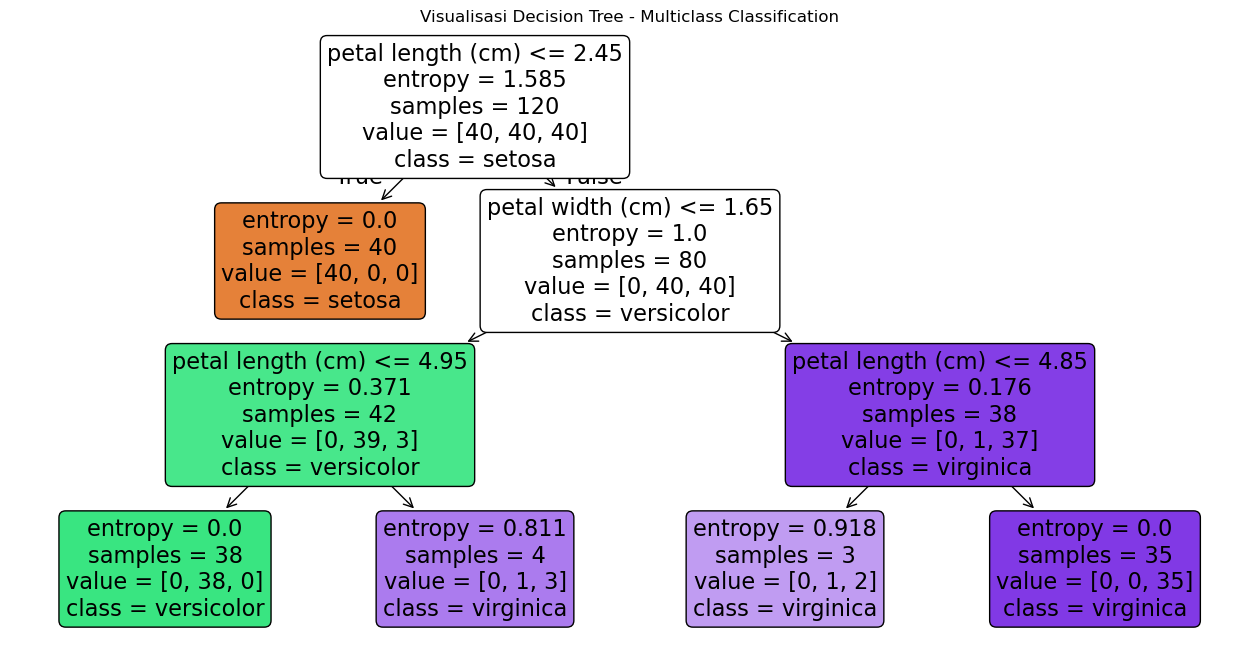

In [16]:
plt.figure(figsize=(16, 8))
plot_tree(
    dt_multi,
    filled=True,
    rounded=True,
    feature_names=iris.feature_names,
    class_names=iris.target_names
)
plt.title("Visualisasi Decision Tree - Multiclass Classification")
plt.show()

## 2.8 Feature Importance

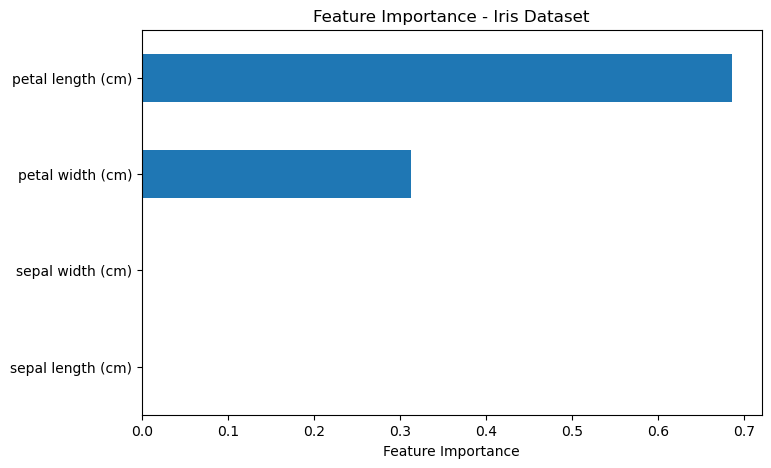

In [17]:
importances2 = pd.Series(dt_multi.feature_importances_, index=iris.feature_names)
importances2 = importances2.sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances2.plot(kind="barh")
plt.title("Feature Importance - Iris Dataset")
plt.xlabel("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

---

# Eksperimen Pengaruh max_depth terhadap Overfitting

Bagian ini menunjukkan secara langsung kenapa regularisasi diperlukan. Model dilatih ulang dengan berbagai nilai max_depth, lalu akurasi training dan testing dibandingkan.

Jika max_depth terlalu besar, akurasi training akan mendekati sempurna, tetapi akurasi testing bisa menurun. Itulah gejala overfitting.

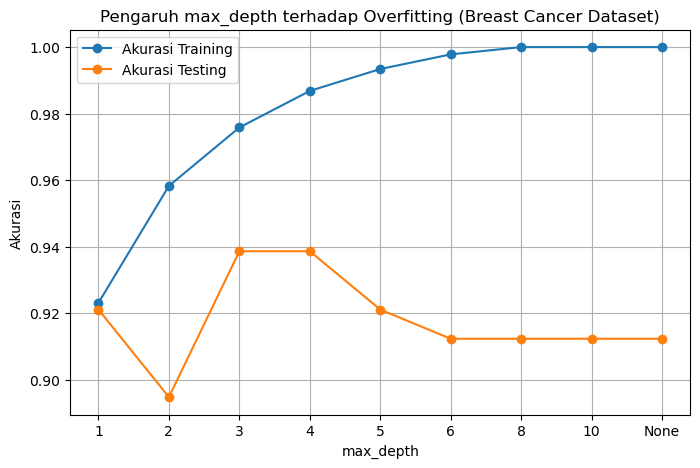

In [18]:
depths = [1, 2, 3, 4, 5, 6, 8, 10, None]
train_scores = []
test_scores = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, model.predict(X_train)))
    test_scores.append(accuracy_score(y_test, model.predict(X_test)))

depth_labels = [str(d) if d is not None else "None" for d in depths]

plt.figure(figsize=(8, 5))
plt.plot(depth_labels, train_scores, marker="o", label="Akurasi Training")
plt.plot(depth_labels, test_scores, marker="o", label="Akurasi Testing")
plt.xlabel("max_depth")
plt.ylabel("Akurasi")
plt.title("Pengaruh max_depth terhadap Overfitting (Breast Cancer Dataset)")
plt.legend()
plt.grid(True)
plt.show()

---

# Ringkasan

1. Binary Classification (Breast Cancer): menggunakan kriteria Gini, hasil evaluasi lengkap dengan confusion matrix dan feature importance.
2. Multiclass Classification (Iris): menggunakan kriteria Entropy, dengan alur kerja yang sama persis seperti bagian binary, menunjukkan bahwa Decision Tree bisa dipakai untuk kedua jenis masalah tanpa perlu perubahan struktur kode yang besar.
3. Bonus: eksperimen max_depth menunjukkan secara langsung bagaimana pohon yang terlalu dalam bisa menyebabkan overfitting, sesuai dengan materi regularisasi yang sudah dibahas sebelumnya.